# O32 R23 SDSS
Testing different methods for calculation of R23 and comparing to O32 values in our SDSS sample.

## Imports

In [57]:
import numpy as np
from astropy.io import fits, ascii
from astropy.modeling import models, fitting
import astropy.units as u
from astropy.table import Table
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import sys 

%matplotlib inline

## Custom functions

In [58]:
def O32_I18(O3_5007,O2_3727):
  # Definition given in Izotov et al. 2018
  return(O3_5007/O2_3727) 

def O32_F22(O3_5007,O2_3726,O2_3729):
  # Definition given in Flury et al. 2022
  return(O3_5007/(O2_3726+O2_3729)) 

def O32_P22(O3_4959,O3_5008,O2_3726,O2_3729):
  # Definition given in Papovich et al. 2022
  return((O3_4959+O3_5008)/(O2_3726+O2_3729)) 

def k_Cardelli(l,Rv=3.1):
  try:
    l=l.to(u.micrometer)
  except:
    print('Wavelength unit invalid')
  if (l<1/1.1*u.micrometer) & (l>1/3.3*u.micrometer):
    x = 1/l.value
    y = x-1.82
    a = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4+ 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7
    k = Rv * a + b
  else:
    print('Wavelength outside the optical range, function not adapted.')
  return(k)

def EBV(fHa,fHb,ha_hb_int=2.87):
  # Intrinsic Halpha to Hbeta ratio ha_hb_int=2.86 obtained for ne=100cm-3 and T=1e4K, but verify this is correct
  l_Ha =  6564.6 *u.Angstrom # Halpha vacuum wavelength 
  l_Hb =  4862.721 *u.Angstrom # Hbeta vacuum wavelength 
  ebv = -2.5 * np.log10(fHa/fHb/ha_hb_int)/(k_Cardelli(l_Ha)-k_Cardelli(l_Hb))
  return(ebv)

def dust_corr_factor(l,ebv):
  kl =  k_Cardelli(l)
  return(10**(0.4*ebv*kl))

def K03(OIII_5007,Hb,NII_6583,Ha):
  K03_left = np.log10(OIII_5007/Hb)
  K03_right = 0.61/(np.log10(NII_6583/Ha)-0.05) + 1.3
  starburst = np.where((K03_left<=K03_right)&(np.log10(NII_6583/Ha)<0.05),1,0) 
  #second condition to avoid going outside the definition range of the function
  return(starburst)

def R23_w4Olines(OII_3727,OII_3729,OIII_4959,OIII_5007,Hb):
  r23 = (OII_3727+OII_3729+OIII_4959+OIII_5007)/(Hb)
  return(r23)

def R23_w3Olines(OII_3727,OIII_4959,OIII_5007,Hb):
  r23 = (OII_3727+OIII_4959+OIII_5007)/(Hb)
  return(r23)

## Definition of constants

In [59]:
l_ha = 6564.614 *u.Angstrom
l_hb = 4862.721 *u.Angstrom
l_O3_4959 = 4960.295 *u.Angstrom
l_O3_5007 = 5008.239 *u.Angstrom
l_O2_3726 = 3727.092 *u.Angstrom
l_O2_3729 = 3729.875 *u.Angstrom
l_N2_6549 = 6549.86 *u.Angstrom
l_N2_6585 = 6585.27 *u.Angstrom
l_SII_6718 = 6718.29 * u.Angstrom
l_SII_6732 = 6732.68 *u.Angstrom
l_OI_6302 = 6302.046 *u.Angstrom

## Paths

In [60]:
data_p = './data/'
fig_p = './figures/'
table_p = data_p + 'SDSS_DR17_table_with_BPT_lines.csv'

## Open tables + apply selection

In [61]:
# Sample selection from Kameswara: 
catalog = ascii.read(table_p, format='csv')
cleaned_catalog = catalog[np.where((catalog['clean']==1) & (catalog['type']==3))]
redshift_cut = cleaned_catalog[np.where((cleaned_catalog['z']>=0.01) & (cleaned_catalog['z']<=0.055))]
mass_cut = redshift_cut[np.where(redshift_cut['logMass']>=8.5)]
snr_sel=3

primary_catalog = mass_cut[np.where((mass_cut['oiii_5007_flux']/mass_cut['oiii_5007_flux_err']>=snr_sel) 
                                    & (mass_cut['oii_3726_flux']/mass_cut['oii_3726_flux_err']>=snr_sel)
                                    & (mass_cut['oii_3729_flux']/mass_cut['oii_3729_flux_err']>=snr_sel)
                                    & (mass_cut['oiii_4959_flux']/mass_cut['oiii_4959_flux_err']>=snr_sel)
                                    & (mass_cut['h_alpha_flux']/mass_cut['h_alpha_flux_err']>=snr_sel)
                                    & (mass_cut['h_beta_flux']/mass_cut['h_beta_flux_err']>=snr_sel)
                                    & (mass_cut['nii_6584_flux']/mass_cut['nii_6584_flux_err']>=snr_sel) )]


/var/folders/xf/gdnc5b2x6jjdr7g00v0lcx740000gn/T/ipykernel_6751/3153901820.py:8: RuntimeWarning: invalid value encountered in divide
  primary_catalog = mass_cut[np.where((mass_cut['oiii_5007_flux']/mass_cut['oiii_5007_flux_err']>=snr_sel)
/var/folders/xf/gdnc5b2x6jjdr7g00v0lcx740000gn/T/ipykernel_6751/3153901820.py:9: RuntimeWarning: invalid value encountered in divide
  & (mass_cut['oii_3726_flux']/mass_cut['oii_3726_flux_err']>=snr_sel)
/var/folders/xf/gdnc5b2x6jjdr7g00v0lcx740000gn/T/ipykernel_6751/3153901820.py:10: RuntimeWarning: invalid value encountered in divide
  & (mass_cut['oii_3729_flux']/mass_cut['oii_3729_flux_err']>=snr_sel)
/var/folders/xf/gdnc5b2x6jjdr7g00v0lcx740000gn/T/ipykernel_6751/3153901820.py:11: RuntimeWarning: invalid value encountered in divide
  & (mass_cut['oiii_4959_flux']/mass_cut['oiii_4959_flux_err']>=snr_sel)
/var/folders/xf/gdnc5b2x6jjdr7g00v0lcx740000gn/T/ipykernel_6751/3153901820.py:12: RuntimeWarning: invalid value encountered in divide
  & (mass_

In [62]:
ebv_sel =  EBV(primary_catalog['h_alpha_flux'] ,primary_catalog['h_beta_flux'] )

f_Ha_corr = primary_catalog['h_alpha_flux'] *dust_corr_factor(l_ha,ebv_sel)
f_Hb_corr = primary_catalog['h_beta_flux']   *dust_corr_factor(l_hb,ebv_sel)
O3_5007_corr = primary_catalog['oiii_5007_flux'] *dust_corr_factor(l_O3_5007,ebv_sel)
O2_3726_corr = primary_catalog['oii_3726_flux'] *dust_corr_factor(l_O2_3726,ebv_sel)
N2_6584_corr = primary_catalog['nii_6584_flux'] *dust_corr_factor(l_N2_6585,ebv_sel)


 Removing AGNs:

In [63]:
startbursts = K03(O3_5007_corr,f_Hb_corr,N2_6584_corr,f_Ha_corr )

In [64]:
t = primary_catalog[startbursts==1]

In [65]:
f_Ha = t['h_alpha_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s 
f_Ha_err = t['h_alpha_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s 
f_Hb = t['h_beta_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s 
f_Hb_err = t['h_beta_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s 
O3_4959 = t['oiii_4959_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s 
O3_4959_err = t['oiii_4959_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s 
O3_5007 = t['oiii_5007_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s
O3_5007_err = t['oiii_5007_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s
O2_3726 = t['oii_3726_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s
O2_3726_err = t['oii_3726_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s 
O2_3729 = t['oii_3729_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s
O2_3729_err = t['oii_3729_flux_err'] *1e-17 *u.erg/u.cm/u.cm/u.s 
N2_6584 = t['nii_6584_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s 
N2_6584 = t['nii_6584_flux'] *1e-17 *u.erg/u.cm/u.cm/u.s 

ebv = EBV(f_Ha,f_Hb)

Ha_corr = f_Ha *dust_corr_factor(l_ha,ebv)
Hb_corr = f_Hb *dust_corr_factor(l_hb,ebv)
O3_4959_corr = O3_4959*dust_corr_factor(l_O3_4959,ebv)
O3_5007_corr = O3_5007*dust_corr_factor(l_O3_5007,ebv)
O2_3726_corr = O2_3726*dust_corr_factor(l_O2_3726,ebv)
O2_3729_corr = O2_3729*dust_corr_factor(l_O2_3729,ebv)
N2_6584_corr =N2_6584*dust_corr_factor(l_N2_6585,ebv)

## Calculate R23

In [66]:
R23_1 = R23_w4Olines(O2_3726_corr ,O2_3729_corr ,O3_4959_corr,O3_5007_corr,Hb_corr)

R23_2 = R23_w3Olines(O2_3726_corr,O3_4959_corr,O3_5007_corr,Hb_corr)

Text(0.5, 0, 'R23, three O lines (Paalvast+18)')

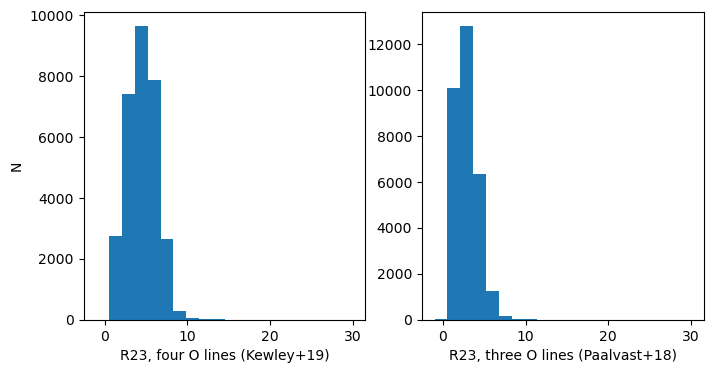

In [67]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(121)
ax.hist(R23_1,20,[-1,30])
ax.set_xlabel('R23, four O lines (Kewley+19)')
ax.set_ylabel('N')
ax =  fig.add_subplot(122)
ax.hist(R23_2,20,[-1,30])
ax.set_xlabel('R23, three O lines (Paalvast+18)')

### Calculate O32

In [68]:
O32_I18_corr = O32_I18(O3_5007_corr,O2_3726_corr)
logO32_I18_corr = np.log10(O32_I18_corr)
logO32_I18_corr_h = np.where(np.isinf(logO32_I18_corr),np.nan,logO32_I18_corr)

### Plot O32 vs R23

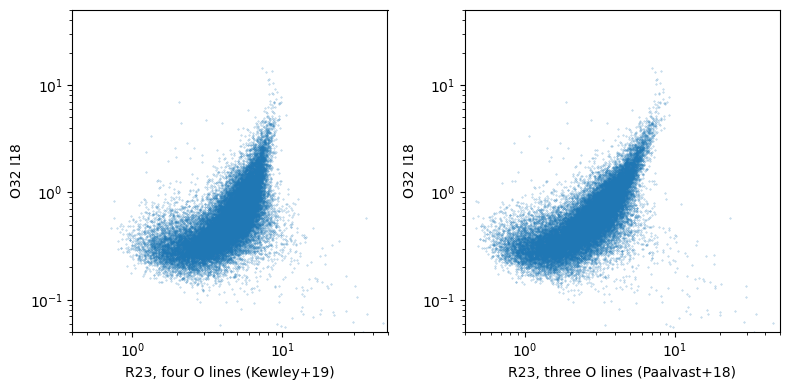

In [69]:
fig = plt.figure(figsize=(2*4,1*4))

ax0 = fig.add_subplot(1, 2, 1)
ax0.scatter(R23_1 ,O32_I18_corr,s=0.1,alpha=0.5)
ax0.set_xlabel('R23, four O lines (Kewley+19)')
ax0.set_ylabel('O32 I18')
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlim([4e-1,50])
ax0.set_ylim([5e-2,50])


ax0 = fig.add_subplot(1, 2, 2)
ax0.scatter(R23_2 ,O32_I18_corr,s=0.1,alpha=0.5)
ax0.set_xlabel('R23, three O lines (Paalvast+18)')
ax0.set_ylabel('O32 I18')
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlim([4e-1,50])
ax0.set_ylim([5e-2,50])

plt.tight_layout()

This seems to be in line with measurements/plots presented in the litterature